<a href="https://colab.research.google.com/github/aatayo/aatayo.github.io/blob/main/AttTCN_NASA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# AttTCN: Attention-based Temporal Convolutional Network for Remaining Useful Life Prediction
# of Lithium-Ion Batteries (NASA dataset)

import numpy as np
import random
import math
import os
import scipy.io
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.nn.utils import weight_norm
from math import sqrt
from datetime import datetime
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
# ─────────────────────────────────────────────
# Step 1. Get device
# ─────────────────────────────────────────────
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [ ]:
# ─────────────────────────────────────────────
# Step 2. Data loading helpers (unchanged from NASA AttMoE)
# ─────────────────────────────────────────────
def convert_to_time(hmm):
    """Convert array to datetime."""
    year, month, day, hour, minute, second = (
        int(hmm[0]), int(hmm[1]), int(hmm[2]),
        int(hmm[3]), int(hmm[4]), int(hmm[5])
    )
    return datetime(year=year, month=month, day=day,
                    hour=hour, minute=minute, second=second)

def loadMat(matfile):
    """Load .mat file and return structured battery data."""
    data = scipy.io.loadmat(matfile)
    filename = matfile.split(".")[0]
    col = data[filename]
    col = col[0][0][0][0]
    size = col.shape[0]

    data = []
    for i in range(size):
        k = list(col[i][3][0].dtype.fields.keys())
        d1, d2 = {}, {}
        if str(col[i][0][0]) != 'impedance':
            for j in range(len(k)):
                t = col[i][3][0][0][j][0]
                l = [t[m] for m in range(len(t))]
                d2[k[j]] = l
        d1['type'] = str(col[i][0][0])
        d1['temp'] = int(col[i][1][0])
        d1['time'] = str(convert_to_time(col[i][2][0]))
        d1['data'] = d2
        data.append(d1)

    return data

def getBatteryCapacity(Battery):
    """Get capacity data from discharge cycles."""
    cycle, capacity = [], []
    i = 1
    for Bat in Battery:
        if Bat['type'] == 'discharge':
            capacity.append(Bat['data']['Capacity'][0])
            cycle.append(i)
            i += 1
    return [cycle, capacity]

In [ ]:
# ─────────────────────────────────────────────
# Step 3. Load NASA data (raw .mat or pre‑extracted .npy)
# ─────────────────────────────────────────────

Battery_list = ['B0005', 'B0006', 'B0007', 'B0018']
Battery = {}
for name in Battery_list:
    print('Load Dataset ' + name + '.mat ...')
    path = name + '.mat'
    data = loadMat(path)
    Battery[name] = getBatteryCapacity(data)

Load Dataset B0005.mat ...


/tmp/ipykernel_3407/4176177353.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  d1['temp'] = int(col[i][1][0])


Load Dataset B0006.mat ...
Load Dataset B0007.mat ...
Load Dataset B0018.mat ...


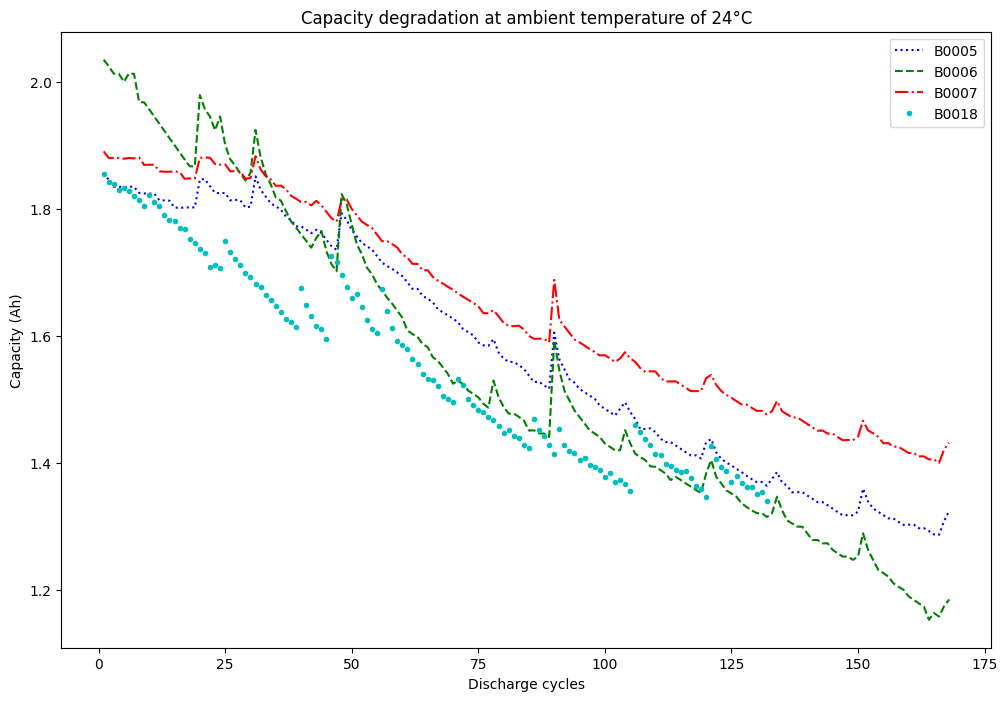

In [ ]:
# ─────────────────────────────────────────────
# Step 4. Capacity degradation figure (optional)
# ─────────────────────────────────────────────
fig, ax = plt.subplots(1, figsize=(12, 8))
color_list = ['b:', 'g--', 'r-.', 'c.']
for name, color in zip(Battery_list, color_list):
    df_result = Battery[name]
    ax.plot(df_result[0], df_result[1], color, label=name)
ax.set(xlabel='Discharge cycles', ylabel='Capacity (Ah)',
       title='Capacity degradation at ambient temperature of 24°C')
plt.legend()
plt.show()


In [ ]:
# ─────────────────────────────────────────────
# Step 5. Sequence building and evaluation helpers
# ─────────────────────────────────────────────
def build_sequences(text, window_size):
    x, y = [], []
    for i in range(len(text) - window_size):
        sequence = text[i:i + window_size]
        target = text[i + 1:i + 1 + window_size]
        x.append(sequence)
        y.append(target)
    return np.array(x), np.array(y)

def get_train_test(data_dict, name, window_size=8):
    data_sequence = data_dict[name][1]   # Index 1 contains capacities
    train_data, test_data = data_sequence[:window_size + 1], data_sequence[window_size + 1:]
    train_x, train_y = build_sequences(text=train_data, window_size=window_size)
    for k, v in data_dict.items():
        if k != name:
            data_x, data_y = build_sequences(text=v[1], window_size=window_size)
            train_x, train_y = np.r_[train_x, data_x], np.r_[train_y, data_y]
    return train_x, train_y, list(train_data), list(test_data)

def relative_error(y_test, y_predict, threshold):
    true_re, pred_re = len(y_test), 0
    for i in range(len(y_test) - 1):
        if y_test[i] <= threshold >= y_test[i + 1]:
            true_re = i - 1
            break
    for i in range(len(y_predict) - 1):
        if y_predict[i] <= threshold:
            pred_re = i - 1
            break
    return abs(true_re - pred_re) / true_re

def evaluation(y_test, y_predict):
    mae = mean_absolute_error(y_test, y_predict)
    rmse = sqrt(mean_squared_error(y_test, y_predict))
    return mae, rmse

def setup_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True

In [ ]:
# ─────────────────────────────────────────────
# Step 6. Build the AttTCN model
# ─────────────────────────────────────────────
class Chomp1d(nn.Module):
    """Remove future time steps to maintain causality."""
    def __init__(self, chomp_size):
        super(Chomp1d, self).__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous()

class TemporalBlock(nn.Module):
    """Residual block with two dilated causal convolutions."""
    def __init__(self, n_inputs, n_outputs, kernel_size, stride, dilation, padding, dropout=0.2):
        super(TemporalBlock, self).__init__()
        self.conv1 = weight_norm(nn.Conv1d(n_inputs, n_outputs, kernel_size,
                                           stride=stride, padding=padding, dilation=dilation))
        self.chomp1 = Chomp1d(padding)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        self.conv2 = weight_norm(nn.Conv1d(n_outputs, n_outputs, kernel_size,
                                           stride=stride, padding=padding, dilation=dilation))
        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        self.net = nn.Sequential(
            self.conv1, self.chomp1, self.relu1, self.dropout1,
            self.conv2, self.chomp2, self.relu2, self.dropout2
        )
        self.downsample = nn.Conv1d(n_inputs, n_outputs, 1) if n_inputs != n_outputs else None
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)

class TemporalConvNet(nn.Module):
    """Stack of TemporalBlocks with exponentially increasing dilation."""
    def __init__(self, num_inputs, num_channels, kernel_size=2, dropout=0.2):
        super(TemporalConvNet, self).__init__()
        layers = []
        num_levels = len(num_channels)
        for i in range(num_levels):
            dilation_size = 2 ** i
            in_channels = num_inputs if i == 0 else num_channels[i-1]
            out_channels = num_channels[i]
            layers += [TemporalBlock(in_channels, out_channels, kernel_size, stride=1,
                                     dilation=dilation_size,
                                     padding=(kernel_size-1) * dilation_size,
                                     dropout=dropout)]
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

class AttTCN(nn.Module):
    """
    Attention-based Temporal Convolutional Network for RUL prediction.
    Input shape: (batch, 1, seq_len)   (capacity window)
    Output: (batch, 1)                 (predicted next capacity)
    """
    def __init__(self, seq_len, num_channels, kernel_size=2, dropout_tcn=0.2,
                 nhead=4, dropout_att=0.0, device='cpu'):
        super(AttTCN, self).__init__()
        self.seq_len = seq_len
        self.tcn = TemporalConvNet(num_inputs=1,
                                   num_channels=num_channels,
                                   kernel_size=kernel_size,
                                   dropout=dropout_tcn)
        self.tcn_out_channels = num_channels[-1]
        # Multi‑head self‑attention on temporal features
        self.attention = nn.MultiheadAttention(embed_dim=self.tcn_out_channels,
                                               num_heads=nhead,
                                               dropout=dropout_att,
                                               batch_first=True)
        self.linear = nn.Linear(self.tcn_out_channels, 1)

    def forward(self, x):
        tcn_out = self.tcn(x)                     # (batch, out_channels, seq_len)
        tcn_out = tcn_out.transpose(1, 2)         # (batch, seq_len, out_channels)
        attn_out, _ = self.attention(tcn_out, tcn_out, tcn_out)  # (batch, seq_len, out_channels)
        last_out = attn_out[:, -1, :]             # use the last time step's representation
        return self.linear(last_out)

In [ ]:
# ─────────────────────────────────────────────
# Step 7. Training function
# ─────────────────────────────────────────────
def train_att_tcn(lr=0.001, feature_size=16, num_channels=None,
                  kernel_size=3, nhead=4, weight_decay=0.0,
                  EPOCH=1000, seed=0, dropout_tcn=0.2, dropout_att=0.0,
                  metric='all', device='cpu'):
    if num_channels is None:
        num_channels = [32, 32, 32]

    score_list, result_list = [], []
    Rated_Capacity = 2.0   # NASA batteries have nominal capacity ~2 Ah

    for i in range(4):
        name = Battery_list[i]
        window_size = feature_size
        train_x, train_y, train_data, test_data = get_train_test(Battery, name, window_size)

        setup_seed(seed)
        model = AttTCN(seq_len=feature_size,
                       num_channels=num_channels,
                       kernel_size=kernel_size,
                       dropout_tcn=dropout_tcn,
                       nhead=nhead,
                       dropout_att=dropout_att,
                       device=device).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        criterion = nn.MSELoss()

        test_x = train_data.copy()
        y_ = [0]                     # placeholder for the first entry
        loss_list = [0]
        mae, rmse, re = 1, 1, 1
        score_, score = [1], [1]

        for epoch in range(EPOCH):
            X = np.reshape(train_x / Rated_Capacity, (-1, 1, feature_size)).astype(np.float32)
            y = np.reshape(train_y[:, -1] / Rated_Capacity, (-1, 1)).astype(np.float32)
            X, y = torch.from_numpy(X).to(device), torch.from_numpy(y).to(device)

            output = model(X)
            loss = criterion(output, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if (epoch + 1) % 100 == 0:
                test_x = train_data.copy()
                point_list = []
                while (len(test_x) - len(train_data)) < len(test_data):
                    x = np.reshape(np.array(test_x[-feature_size:]) / Rated_Capacity,
                                   (-1, 1, feature_size)).astype(np.float32)
                    x = torch.from_numpy(x).to(device)
                    with torch.no_grad():
                        pred = model(x)
                    next_point = pred.cpu().data.numpy()[0, 0] * Rated_Capacity
                    test_x.append(next_point)
                    point_list.append(next_point)
                y_.append(point_list)
                loss_list.append(loss.item())
                mae, rmse = evaluation(y_test=test_data, y_predict=y_[-1])
                re = relative_error(y_test=test_data, y_predict=y_[-1],
                                    threshold=Rated_Capacity * 0.7)

            if metric == 're':
                score = [re]
            elif metric == 'mae':
                score = [mae]
            elif metric == 'rmse':
                score = [rmse]
            else:
                score = [re, mae, rmse]

            if (loss.item() < 1e-3) and (score_[0] < score[0]):
                break
            score_ = score.copy()

        score_list.append(score_)
        result_list.append(y_[-1])
    return score_list, result_list


In [ ]:
# ─────────────────────────────────────────────
# Step 8. Grid‑search for key hyperparameters
# ─────────────────────────────────────────────
Rated_Capacity = 2.0
feature_size = 16         # as used in original NASA AttMoE
EPOCH = 2000
nhead = 4
weight_decay = 0.0
dropout_tcn = 0.2
dropout_att = 0.0
kernel_size = 3
metric = 'all'

# Search space: learning rate, number of filters (hidden_dim), number of TCN layers
for lr in [1e-4, 1e-3]:
    for hidden_dim in [32, 64, 128]:
        for num_layers in [2, 3, 4]:
            num_channels = [hidden_dim] * num_layers
            print(f'lr:{lr}, hidden_dim:{hidden_dim}, num_layers:{num_layers}')

            SCORE = []
            for seed in range(5):
                print(f'seed:{seed}')
                score_list, _ = train_att_tcn(
                    lr=lr, feature_size=feature_size,
                    num_channels=num_channels,
                    kernel_size=kernel_size,
                    nhead=nhead,
                    weight_decay=weight_decay,
                    EPOCH=EPOCH, seed=seed,
                    dropout_tcn=dropout_tcn,
                    dropout_att=dropout_att,
                    metric=metric, device=device
                )
                print('------------------------------------------------------------------')
                for s in score_list:
                    SCORE.append(s)

            if metric != 'all':
                print(f'{metric} mean: {np.mean(np.array(SCORE)):<6.4f}')
            else:
                mlist = ['re', 'mae', 'rmse']
                for i in range(3):
                    s = [line[i] for line in SCORE]
                    print(f'{mlist[i]} mean: {np.mean(np.array(s)):<6.4f}')
            print('===================================================================')

lr:0.0001, hidden_dim:32, num_layers:2
seed:0


/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


------------------------------------------------------------------
seed:1


/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


------------------------------------------------------------------
seed:2


...

------------------------------------------------------------------
seed:3


/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


------------------------------------------------------------------
seed:4


/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


------------------------------------------------------------------
re mean: 0.2571
mae mean: 0.0826
rmse mean: 0.0911


In [ ]:
# ─────────────────────────────────────────────
# Step 9. Final training with the best hyperparameters
# ─────────────────────────────────────────────
# (Choose the best combination from the grid search above)
lr = 1e-4
hidden_dim = 64
num_layers = 3
num_channels = [hidden_dim] * num_layers

print('Final evaluation with best parameters:')
SCORE = []
for seed in range(5):
    print(f'seed:{seed}')
    score_list, _ = train_att_tcn(
        lr=lr, feature_size=feature_size,
        num_channels=num_channels,
        kernel_size=kernel_size,
        nhead=nhead,
        weight_decay=weight_decay,
        EPOCH=EPOCH, seed=seed,
        dropout_tcn=dropout_tcn,
        dropout_att=dropout_att,
        metric='all', device=device
    )
    print('------------------------------------------------------------------')
    for s in score_list:
        SCORE.append(s)

mlist = ['re', 'mae', 'rmse']
for i in range(3):
    s = [line[i] for line in SCORE]
    print(f'{mlist[i]} mean: {np.mean(np.array(s)):<6.4f}')
print('===================================================================')

Final evaluation with best parameters:
seed:0


/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


------------------------------------------------------------------
seed:1


/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


------------------------------------------------------------------
seed:2


...

------------------------------------------------------------------
seed:3


/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


------------------------------------------------------------------
seed:4


/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


------------------------------------------------------------------
re mean: 0.1963
mae mean: 0.0830
rmse mean: 0.0957
